## **EEG Analisys with MNE Library**


In [21]:
!pip install mne matplotlib numpy scipy pandas pyqt5 ipympl
%matplotlib inline
#qt5 

### **1. Plot the raw signal of all channels**


> #### 1.1 Data extraction and transformation

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne

# IMPORTAÇÃO E CONFIGURAÇÃO
dfEEG = pd.read_csv('data/SUBJECTS/SUBJECT01/SUBJECT01_Trial_01_EEG.csv')
sampling_rate = 128
channels_list = [                                                      # Total: 32 canais
    "AF3", "AF4",
    "F3", "F1", "Fz", "F2", "F4",
    "FC3", "FC1", "FCz", "FC2", "FC4",
    "C3", "C1", "Cz", "C2", "C4",
    "CP3", "CP1", "CPz", "CP2", "CP4",                                 # CPz incluso (faltante no artigo)
    "P3", "P1", "Pz", "P2", "P4",
    "PO3", "POz", "PO4",
    "O1", "O2"
]
channel_to_idx = {ch: i for i, ch in enumerate(channels_list)}          # Objeto de mapeamento canal -> índice

# SEPARAR TRIGGERS E SINAIS
stim_data = dfEEG["Triggers"].values.reshape(1,-1)                      # Valores dos marcadores de estímulos (1, n_amostras)
eeg_data = dfEEG[[str(ch) for ch in range(0,32)]].values.T              # Valores dos canais EEG (32, n_amostras)
extra_data = dfEEG[[str(ch) for ch in range(32, 38)]].values.T          # Valores de funções extras(giroscópio, acelerômetro, timestamps)

# TRANSFORMAR PARA O FORMATO MNE (LINHAS: CANAIS X COLUNAS: SINAIS) E JUNTAR OS MARCADORES
data_full = np.vstack([eeg_data, stim_data])

# VERIFICAR FORMATO DE DADOS
print(data_full.shape)
print(type(data_full))


(33, 12865)
<class 'numpy.ndarray'>


> #### 1.2 Inspect raw data

----DATA INFORMATION----
 <Info | 7 non-empty values
 bads: []
 ch_names: AF3, AF4, F3, F1, Fz, F2, F4, FC3, FC1, FCz, FC2, FC4, C3, C1, ...
 chs: 32 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 64.0 Hz
 meas_date: unspecified
 nchan: 33
 projs: []
 sfreq: 128.0 Hz
>

----DATA SHAPE----
 (33, 12865)
DURATION: 100.5 s


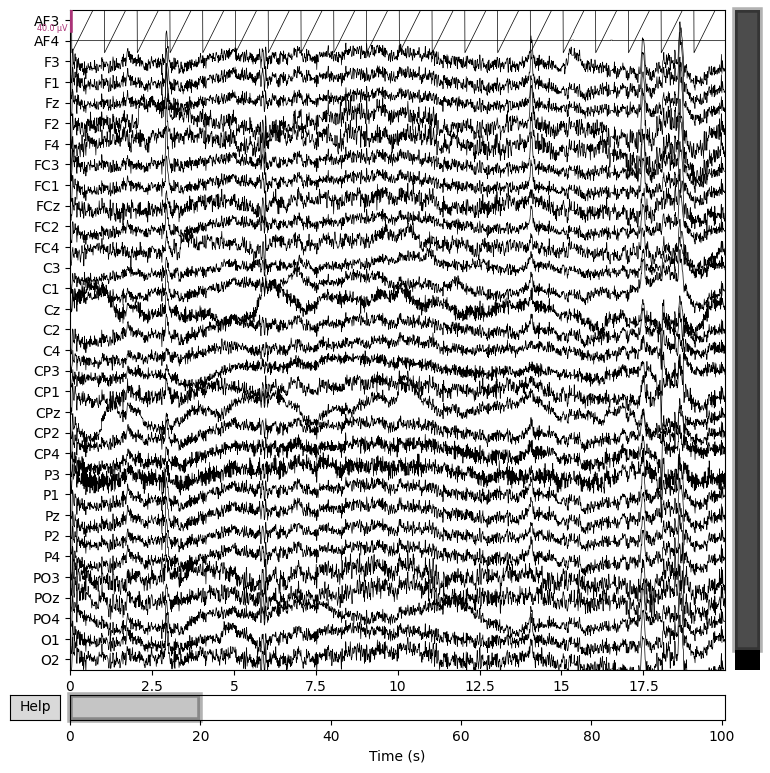

In [23]:
# CONVERTER DE MICROVOLTS PARA VOLTZ
data_full[0:32,:] = data_full[0:32,:] * 1e-6

# CRIAR INFORMAÇÕES DE DOS DADOS MNE
info_full = mne.create_info(
    ch_names=channels_list + ["STI 014"],
    sfreq=sampling_rate,
    ch_types=["eeg"] * 32 + ["stim"]
)

# CRIAR OBJETO DE DADOS BRUTOS
raw = mne.io.RawArray(data_full, info_full, verbose=False)

# VERIFICAR INFO DOS DADOS
print("----DATA INFORMATION----\n", raw.info)     
print("\n----DATA SHAPE----\n",raw.get_data().shape)
print(f"DURATION: {raw.times[-1]:.1f} s")

# GRÁFICO
raw.plot(duration=20, n_channels=32);

### 2. Extract and inspect Events

> #### 2.1 Set montage system

In [24]:
# MOSTRAR LISTA DE MONTAGENS DISPONÍVEIS
#print(mne.channels.get_builtin_montages(descriptions=False))

# ATIVAR MONTAGEM SELECIONADA
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage=montage, on_missing='warn')
print("Montage applied!")

Montage applied!


> #### 2.2 Create and count Events

In [25]:
# MAPEAMENTO DE MARCADORES DE EVENTOS
event_id = {
    "trial_start":      768,
    "preparation":      771,
    "exec_start":       7711,
    "exec_end":         7712,
    "trial_end":        1000,
    "session_boundary": 32766,
}

# CRIAR OBJETO DE EVENTOS
events = mne.find_events(
    raw, 
    stim_channel="STI 014", 
    initial_event=True,
    consecutive=False                                           # consecutive=False -> Importante para ser compatível com o formato de marcadores
                                                                # do dataset
)

print("EVENTS SHAPE:", events.shape)                            # TABELA: amostra onde acontece o evento, valor anterior, código do evento
print(events[:10])

print("\n----EVENTS COUNT----")
for nome, codigo in event_id.items():
    n = (events[:, 2] == codigo).sum()
    print(f"  {nome:20s} ({codigo}): {n} ocorrências")

Finding events on: STI 014
41 events found on stim channel STI 014
Event IDs: [  768   771  1000  7711  7712 32766]
EVENTS SHAPE: (41, 3)
[[   0    0  771]
 [ 154    0 7711]
 [ 793    0 7712]
 [1050    0 1000]
 [1286    0  771]
 [1478    0 7711]
 [2108    0 7712]
 [2372    0 1000]
 [2550    0  771]
 [2742    0 7711]]

----EVENTS COUNT----
  trial_start          (768): 1 ocorrências
  preparation          (771): 9 ocorrências
  exec_start           (7711): 10 ocorrências
  exec_end             (7712): 10 ocorrências
  trial_end            (1000): 10 ocorrências
  session_boundary     (32766): 1 ocorrências


> #### 2.2 Visualize events

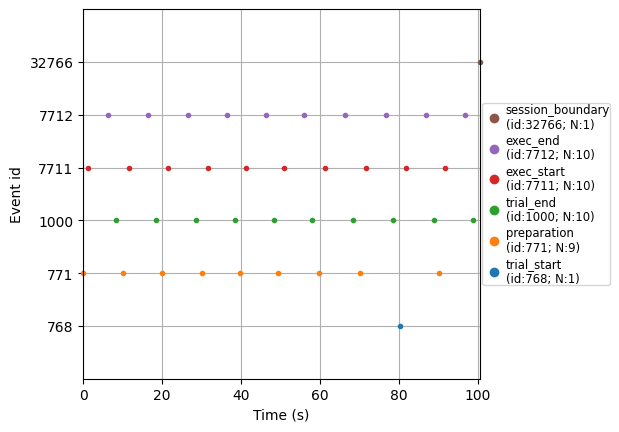

In [26]:
mne.viz.plot_events(events, sfreq=sampling_rate, event_id=event_id);

### 3. Create and inspect Epochs

In [27]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=-0.5,
    tmax=5,
    baseline=(None, 0),
    picks="eeg",
    preload=True,
    verbose=False
)

print(epochs.get_data().shape)                          # → (n_trials, n_canais, n_amostras_na_janela)

print("Eixo de tempo (s):", epochs.times[[0, -1]])
print("Canais:", epochs.ch_names)

# VER EPOCHS DE CADA FASE
print(epochs["trial_start"].get_data().shape)
print(epochs["preparation"].get_data().shape)
print(epochs["exec_start"].get_data().shape)
print(epochs["exec_end"].get_data().shape)
print(epochs["trial_end"].get_data().shape)
#print(epochs["session_boundary"].get_data().shape)

(37, 32, 705)
Eixo de tempo (s): [-0.5  5. ]
Canais: ['AF3', 'AF4', 'F3', 'F1', 'Fz', 'F2', 'F4', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C3', 'C1', 'Cz', 'C2', 'C4', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P3', 'P1', 'Pz', 'P2', 'P4', 'PO3', 'POz', 'PO4', 'O1', 'O2']
(1, 32, 705)
(8, 32, 705)
(10, 32, 705)
(9, 32, 705)
(9, 32, 705)


### 4. Time Domain Analysis (ERPs)

> #### 4.1 Analysis of central area (Premotor Area e Supplementary Motor Area)

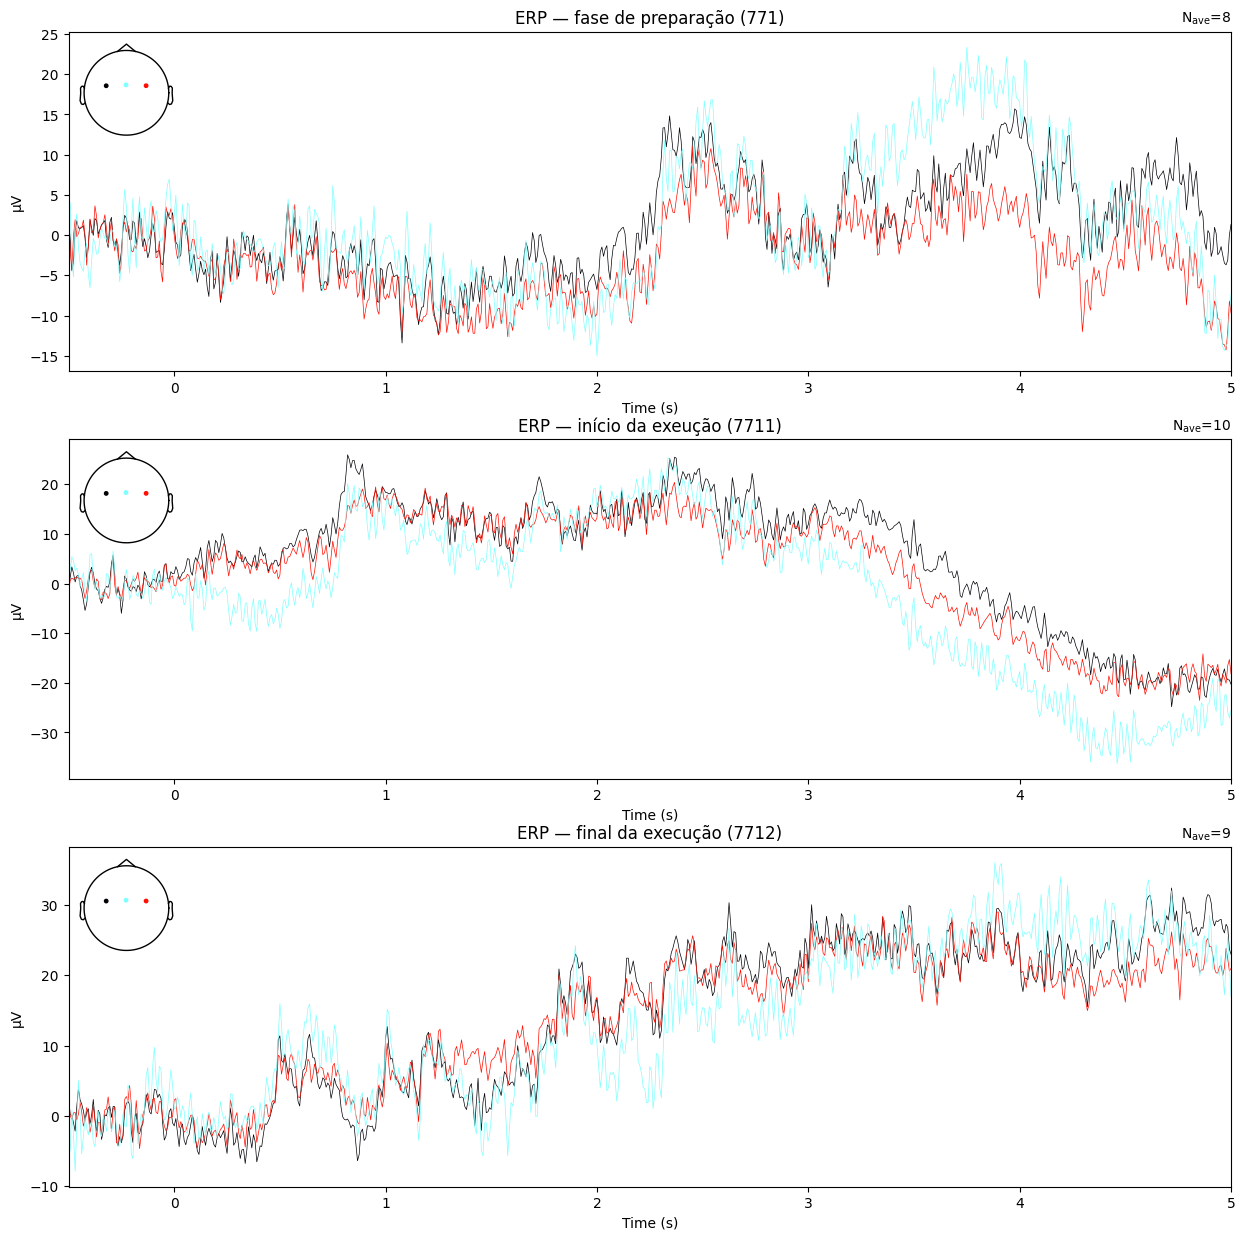

In [28]:
# MÉDIA DE TODAS AS TENTATIVAS DE UM EVENTO (ERPs)
evoked_prep = epochs["preparation"].average()
evoked_exec_start = epochs["exec_start"].average()
evoked_exec_end = epochs["exec_end"].average()

# ESCOLHER UM CANAIS
picks_central_area = ["C3", "C4", "Cz"]

# CONFIGURAÇÃO DE GRÁFICOS CONJUNTOS
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

evoked_prep.plot(axes=axes[0], picks=picks_central_area, spatial_colors=True, show=False);                 # spatial_colors: Necessário ter uma montagem aplicada.
evoked_exec_start.plot(axes=axes[1], picks=picks_central_area, spatial_colors=True, show=False);
evoked_exec_end.plot(axes=axes[2], picks=picks_central_area, spatial_colors=True, show=False);

axes[0].set_title("ERP — fase de preparação (771)")
axes[1].set_title("ERP — início da exeução (7711)")
axes[2].set_title("ERP — final da execução (7712)")
plt.show()

> #### 4.2 Analysis of central parietal area (Motor Area)

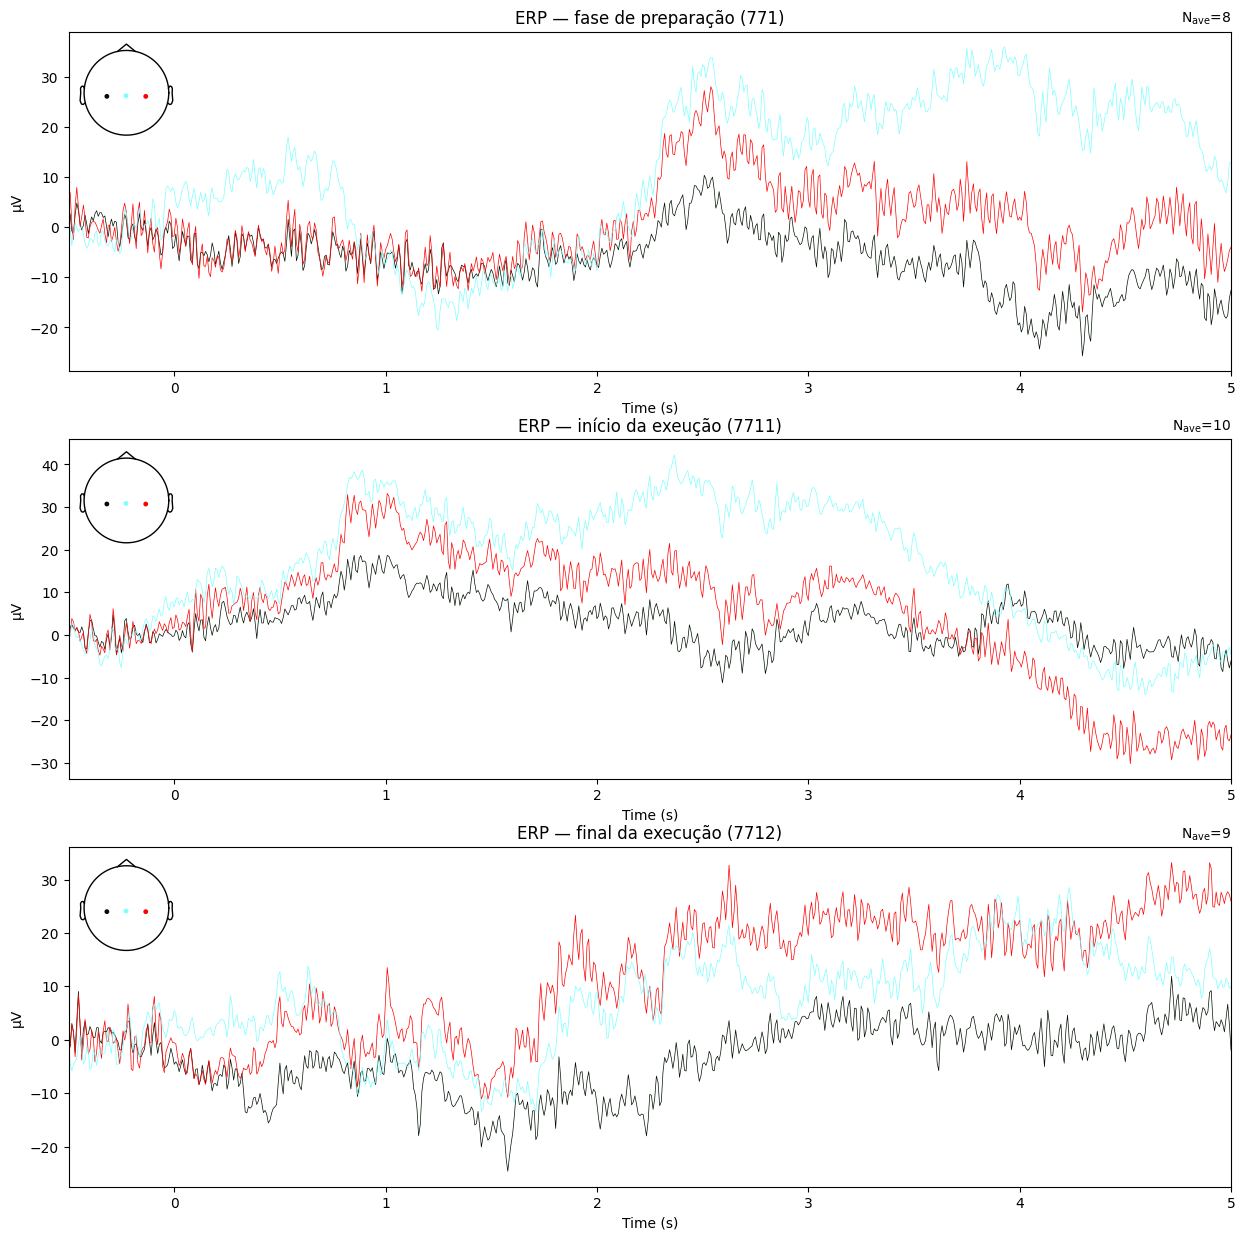

In [29]:
# ESCOLHER UM CANAIS
picks_centralparietal_area = ["CP3", "CP4", "CPz"]

# CONFIGURAÇÃO DE GRÁFICOS CONJUNTOS
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

evoked_prep.plot(axes=axes[0], picks=picks_centralparietal_area, spatial_colors=True, show=False);                 # spatial_colors: Necessário ter uma montagem aplicada.
evoked_exec_start.plot(axes=axes[1], picks=picks_centralparietal_area, spatial_colors=True, show=False);
evoked_exec_end.plot(axes=axes[2], picks=picks_centralparietal_area, spatial_colors=True, show=False);

axes[0].set_title("ERP — fase de preparação (771)")
axes[1].set_title("ERP — início da exeução (7711)")
axes[2].set_title("ERP — final da execução (7712)")
plt.show()

### 5. Frequency Domain Analysis (PSDs)

Effective window size : 16.000 (s)
Plotting power spectral density (dB=True).


/home/kaique-ivo/Documentos/arquivos-vscode/neuroscience/eeg_emg_analysis/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


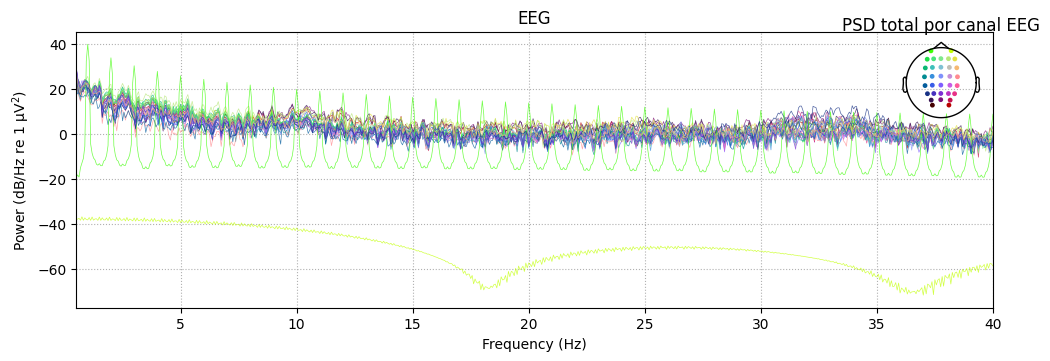

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/tmp/ipykernel_121155/3563030878.py:8: UserWarning: Zero value in spectrum for channel AF4
  epochs["preparation"].compute_psd(fmin=0.5, fmax=40).plot()
/home/kaique-ivo/Documentos/arquivos-vscode/neuroscience/eeg_emg_analysis/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


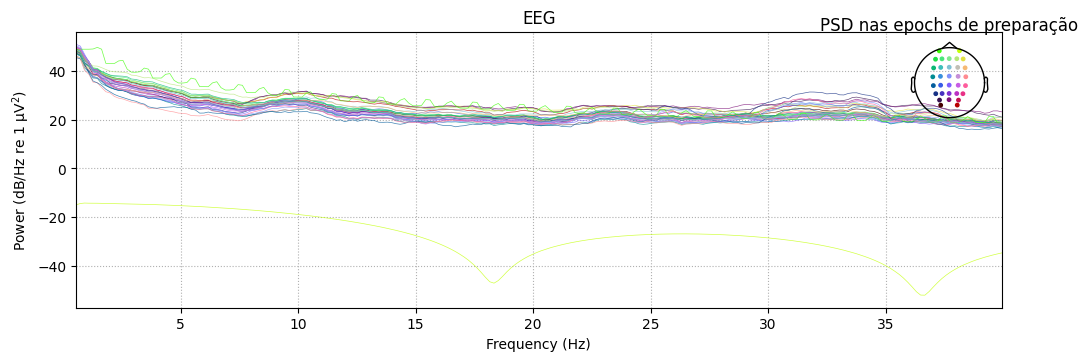

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/tmp/ipykernel_121155/3563030878.py:12: UserWarning: Zero value in spectrum for channel AF4
  epochs["exec_start"].compute_psd(fmin=0.5, fmax=40).plot()
/home/kaique-ivo/Documentos/arquivos-vscode/neuroscience/eeg_emg_analysis/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


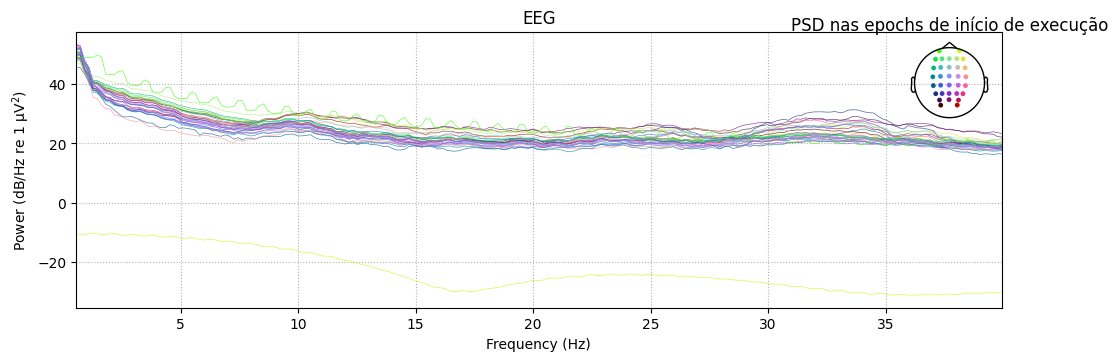

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/tmp/ipykernel_121155/3563030878.py:16: UserWarning: Zero value in spectrum for channel AF4
  epochs["exec_end"].compute_psd(fmin=0.5, fmax=40).plot()
/home/kaique-ivo/Documentos/arquivos-vscode/neuroscience/eeg_emg_analysis/.venv/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


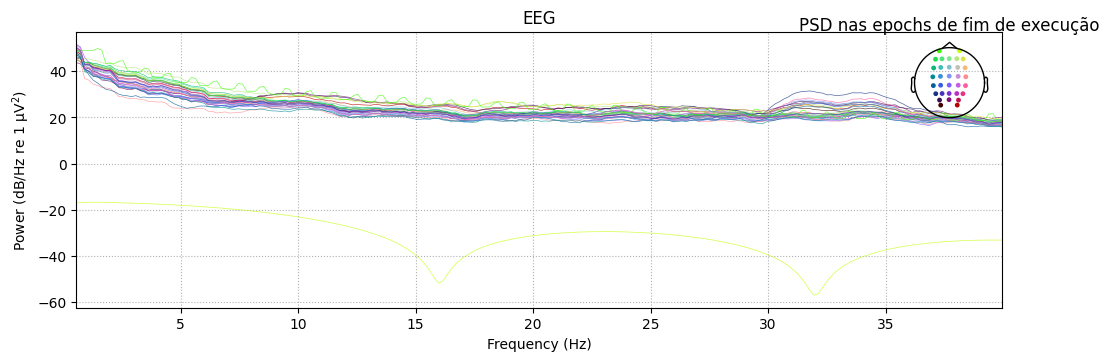

In [ ]:
# ESPECTRO DE POTÊNCIA DO SINAL BRUTO
spectrum = raw.compute_psd(method="welch", fmin=0.5, fmax=40)
spectrum.plot(average=False)     # uma linha por canal
plt.title("PSD total por canal EEG")
plt.show()

# PSD por evento (dentro dos epochs)
epochs["preparation"].compute_psd(fmin=0.5, fmax=40).plot()
plt.title("PSD nas epochs de preparação")
plt.show()

epochs["exec_start"].compute_psd(fmin=0.5, fmax=40).plot()
plt.title("PSD nas epochs de início de execução")
plt.show()

epochs["exec_end"].compute_psd(fmin=0.5, fmax=40).plot()
plt.title("PSD nas epochs de fim de execução")
plt.show()